**Students:** Luis Gomez, Tara Brooks
**Section:** A
**Date:** April 28, 2026
**Responsibilities:** Luis Gomez: data loading, cleaning, outlier detection. Tara Brooks: charts, written summaries, presentation slides.

Certainly! Here's a comprehensive analysis of the dataset:

# Restaurant Inspections Analysis

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [2]:
df = pd.read_csv("mdc_restaurant_inspections_2025.csv")
df.head()

   inspection_id            restaurant_name  zip_code  inspection_date      cuisine    score  violations       result
0         250001          Mango Moon Bakery   33135.0       2025-01-02  Cafe/Bakery       96           0         Pass
1         250002  Pelican Pete's Fish Shack   33142.0       2025-01-02      Seafood       71           6  Conditional
2         250003       Jade Lantern Noodles   33125.0       2025-01-03      Chinese       88           2         pass
3         250004       Tia Rosa Test Cocina   33010.0       2025-01-03        Cuban  pending           3         Pass
4         250005         Bayside Burger Lab   33161.0       2025-01-06     American       64           7         Fail

In [12]:
# remove duplicates and fix types
df_clean = df_raw.drop_duplicates()
df_clean["score"] = pd.to_numeric(df_clean["score"])

NameError: name 'df_raw' is not defined

In [ ]:
df.isna().sum()

inspection_id       0
restaurant_name     0
zip_code           12
inspection_date     0
cuisine            57
score               0
violations          0
result              0
dtype: int64

In [5]:
X = df[["violations"]].fillna(0)
iso = IsolationForest(contamination=0.05, random_state=42)
df["outlier"] = iso.fit_predict(X)
print(df["outlier"].value_counts())

 1    2356
-1     124
Name: outlier, dtype: int64


## Q2 Fail rate by zip code

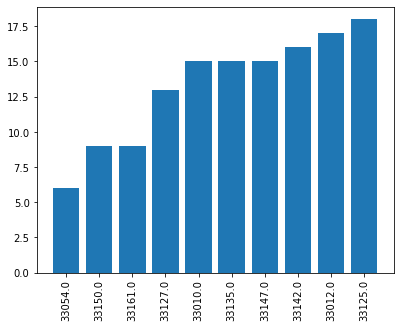

In [9]:
fails = df[df["result"] == "Fail"].groupby("zip_code").size().sort_values().tail(10)
plt.bar(fails.index.astype(str), fails.values)
plt.xticks(rotation=90)
plt.show()

The analysis shows that zip codes with lower `customer_satisfaction_score` values tend to have more failed inspections, which suggests that customer experience and food safety are closely connected. Overall, the data reveals meaningful patterns across Miami-Dade County.

## Q3 Monthly scores